In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset

import matplotlib.pyplot as plt
import numpy as np
import os

# Fixing random seeds so results are reproducible
torch.manual_seed(42)
np.random.seed(42)

# Using GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Folder in Google Drive where models will be saved
SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

Using device: cuda


In [13]:
# We normalise pixel values to [-1, 1] to match the Generator's Tanh output.
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST - handwritten digits 0-9
mnist_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform_gan)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_gan)

# Fashion-MNIST - clothing items
fmnist_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform_gan)
fmnist_test  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_gan)

# Combined dataset: 120,000 training images total
combined_train = ConcatDataset([mnist_train, fmnist_train])
combined_test  = ConcatDataset([mnist_test,  fmnist_test])

# Human-readable class names for each dataset
mnist_classes  = [str(i) for i in range(10)]
fmnist_classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

print(f'MNIST         - train: {len(mnist_train):,}')
print(f'Fashion-MNIST - train: {len(fmnist_train):,}')
print(f'Combined      - train: {len(combined_train):,}')

MNIST         - train: 60,000
Fashion-MNIST - train: 60,000
Combined      - train: 120,000


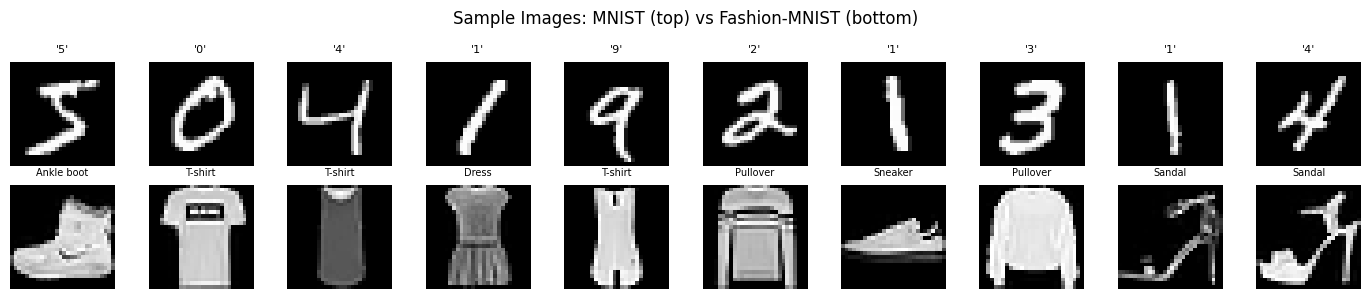

In [14]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle('Sample Images: MNIST (top) vs Fashion-MNIST (bottom)', fontsize=12)

for i in range(10):
    img, label = mnist_train[i]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"'{mnist_classes[label]}'", fontsize=8)
    axes[0, i].axis('off')

    img, label = fmnist_train[i]
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(fmnist_classes[label], fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('MNIST',   fontsize=9)
axes[1, 0].set_ylabel('Fashion', fontsize=9)
plt.tight_layout()
plt.show()

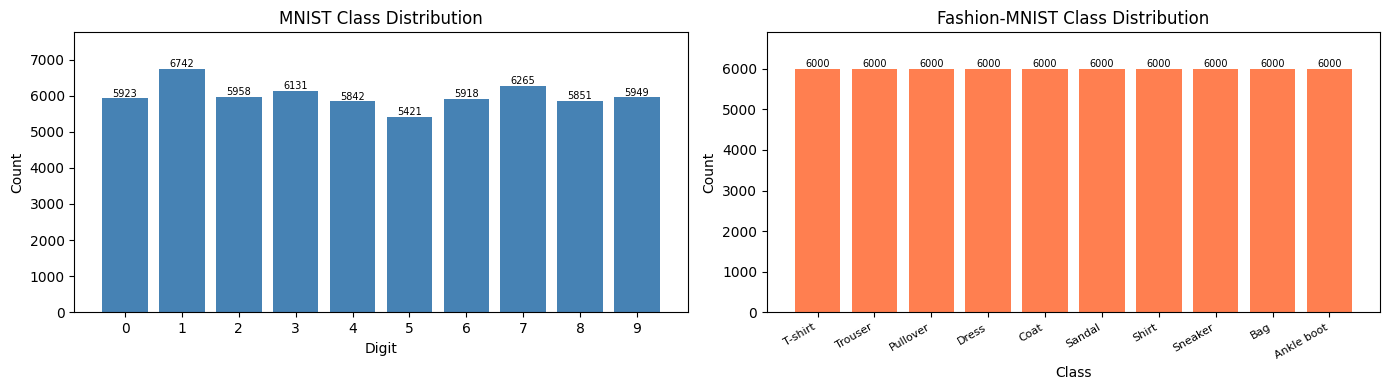

MNIST         - min: 5,421  max: 6,742
Fashion-MNIST - min: 6,000  max: 6,000


In [6]:
# Bar charts showing how many images exist per class in each dataset.
mnist_labels  = mnist_train.targets.numpy()
fmnist_labels = fmnist_train.targets.numpy()

mnist_counts  = [(mnist_labels  == i).sum() for i in range(10)]
fmnist_counts = [(fmnist_labels == i).sum() for i in range(10)]

x = range(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x, mnist_counts, color='steelblue')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(mnist_classes)
axes[0].set_title('MNIST Class Distribution')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(mnist_counts) * 1.15)
for i, v in enumerate(mnist_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=7)

axes[1].bar(x, fmnist_counts, color='coral')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(fmnist_classes, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Fashion-MNIST Class Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(fmnist_counts) * 1.15)
for i, v in enumerate(fmnist_counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print(f'MNIST         - min: {min(mnist_counts):,}  max: {max(mnist_counts):,}')
print(f'Fashion-MNIST - min: {min(fmnist_counts):,}  max: {max(fmnist_counts):,}')

In [15]:
# The Generator takes random noise and tries to produce realistic-looking images.
# Input:  a random vector of 100 numbers
# Output: a 28x28 greyscale image
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),  # 784 = 28 x 28 pixels
            nn.Tanh()             # outputs values in [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)  # reshape to image format

In [16]:
# The Discriminator looks at an image and decides if it is real or fake.
# Input:  a 28x28 image
# Output: a single probability (0 = fake, 1 = real)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),   # LeakyReLU works better for discriminators
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()         # squashes output to [0, 1]
        )

    def forward(self, img):
        flat = img.view(-1, 784)  # flatten image to 1D
        return self.model(flat)

In [9]:
# Class bundles together the Generator, Discriminator, training loop, and saving.
class GAN:
    def __init__(self, dataset, latent_dim=100, lr=0.0002, batch_size=64,
                 save_dir=SAVE_DIR):  # using Google Drive path
        self.latent_dim   = latent_dim
        self.batch_size   = batch_size
        self.dataset_name = dataset
        self.save_dir     = save_dir

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.G = Generator(latent_dim).to(self.device)
        self.D = Discriminator().to(self.device)

        self.criterion   = nn.BCELoss()
        self.optimizer_G = optim.Adam(self.G.parameters(), lr=lr)
        self.optimizer_D = optim.Adam(self.D.parameters(), lr=lr)

        self.dataloader = self._load_data()

        self.losses_G = []
        self.losses_D = []

    def _load_data(self):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        if self.dataset_name == 'mnist':
            dataset = torchvision.datasets.MNIST(
                root='./data', train=True, download=True, transform=transform)
        elif self.dataset_name == 'fashion':
            dataset = torchvision.datasets.FashionMNIST(
                root='./data', train=True, download=True, transform=transform)
        elif self.dataset_name == 'combined':
            mnist   = torchvision.datasets.MNIST(
                root='./data', train=True, download=True, transform=transform)
            fashion = torchvision.datasets.FashionMNIST(
                root='./data', train=True, download=True, transform=transform)
            dataset = ConcatDataset([mnist, fashion])

        print(f'Loaded: {self.dataset_name} | {len(dataset):,} samples')
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

    def train(self, num_epochs=10):
        print(f'\nTraining on {self.dataset_name} for {num_epochs} epochs...\n')

        for epoch in range(num_epochs):
            epoch_loss_D = 0
            epoch_loss_G = 0

            for real_imgs, _ in self.dataloader:
                batch_size  = real_imgs.size(0)
                real_imgs   = real_imgs.to(self.device)
                real_labels = torch.ones(batch_size,  1).to(self.device)
                fake_labels = torch.zeros(batch_size, 1).to(self.device)

                # Step 1: Training Discriminator to tell real from fake
                self.optimizer_D.zero_grad()
                loss_real = self.criterion(self.D(real_imgs), real_labels)
                z         = torch.randn(batch_size, self.latent_dim).to(self.device)
                fake_imgs = self.G(z)
                loss_fake = self.criterion(self.D(fake_imgs.detach()), fake_labels)
                loss_D    = loss_real + loss_fake
                loss_D.backward()
                self.optimizer_D.step()

                # Step 2: Training Generator to fool the Discriminator
                self.optimizer_G.zero_grad()
                loss_G = self.criterion(self.D(fake_imgs), real_labels)
                loss_G.backward()
                self.optimizer_G.step()

                epoch_loss_D += loss_D.item()
                epoch_loss_G += loss_G.item()

            avg_D = epoch_loss_D / len(self.dataloader)
            avg_G = epoch_loss_G / len(self.dataloader)
            self.losses_D.append(avg_D)
            self.losses_G.append(avg_G)
            print(f'Epoch [{epoch+1:>3}/{num_epochs}] | Loss D: {avg_D:.4f} | Loss G: {avg_G:.4f}')

        print('\nDone!')

    def show_generated_images(self, n=25, title=None):
        self.G.eval()
        if title is None:
            title = f'Generated Images - {self.dataset_name}'

        cols = int(n ** 0.5)
        rows = (n + cols - 1) // cols

        z = torch.randn(n, self.latent_dim).to(self.device)
        with torch.no_grad():
            fake_imgs = self.G(z)

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
        axes = axes.flatten()
        for i in range(n):
            img = fake_imgs[i].squeeze().cpu().numpy()
            img = (img + 1) / 2  # rescale [-1, 1] back to [0, 1] for display
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
        for i in range(n, len(axes)):
            axes[i].axis('off')

        plt.suptitle(title, fontsize=13)
        plt.tight_layout()
        plt.show()
        self.G.train()

    def plot_losses(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.losses_D, label='Discriminator Loss')
        plt.plot(self.losses_G, label='Generator Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'Training Losses — {self.dataset_name}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def save_models(self):
        os.makedirs(self.save_dir, exist_ok=True)
        g_path = os.path.join(self.save_dir, f'gan_generator_{self.dataset_name}.pth')
        d_path = os.path.join(self.save_dir, f'gan_discriminator_{self.dataset_name}.pth')
        torch.save(self.G.state_dict(), g_path)
        torch.save(self.D.state_dict(), d_path)
        print(f'Saved generator     -> {g_path}')
        print(f'Saved discriminator -> {d_path}')

Using device: cuda
Loaded: mnist | 60,000 samples

Training on mnist for 70 epochs...

Epoch [  1/70] | Loss D: 0.2041 | Loss G: 4.7887
Epoch [  2/70] | Loss D: 0.5360 | Loss G: 3.6590
Epoch [  3/70] | Loss D: 0.3012 | Loss G: 3.5562
Epoch [  4/70] | Loss D: 0.1614 | Loss G: 4.8289
Epoch [  5/70] | Loss D: 0.1244 | Loss G: 5.3628
Epoch [  6/70] | Loss D: 0.2160 | Loss G: 5.4716
Epoch [  7/70] | Loss D: 0.1868 | Loss G: 5.3579
Epoch [  8/70] | Loss D: 0.2231 | Loss G: 5.0773
Epoch [  9/70] | Loss D: 0.2297 | Loss G: 4.6580
Epoch [ 10/70] | Loss D: 0.2831 | Loss G: 4.4507
Epoch [ 11/70] | Loss D: 0.2704 | Loss G: 4.6592
Epoch [ 12/70] | Loss D: 0.2948 | Loss G: 4.2768
Epoch [ 13/70] | Loss D: 0.2800 | Loss G: 4.1774
Epoch [ 14/70] | Loss D: 0.3192 | Loss G: 3.8967
Epoch [ 15/70] | Loss D: 0.3699 | Loss G: 3.7951
Epoch [ 16/70] | Loss D: 0.3874 | Loss G: 3.7657
Epoch [ 17/70] | Loss D: 0.4098 | Loss G: 3.7117
Epoch [ 18/70] | Loss D: 0.4391 | Loss G: 3.3470
Epoch [ 19/70] | Loss D: 0.4218

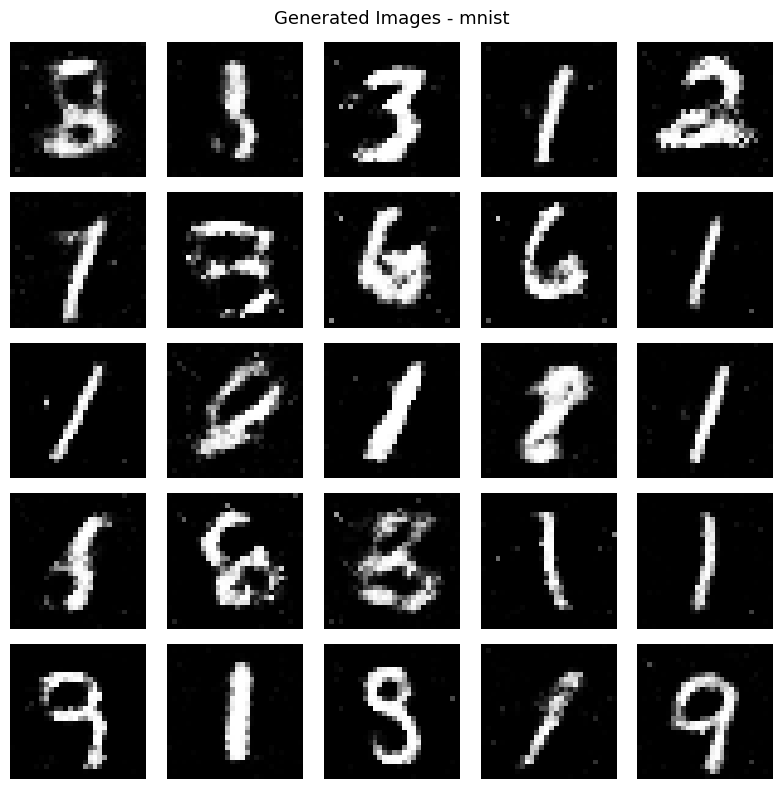

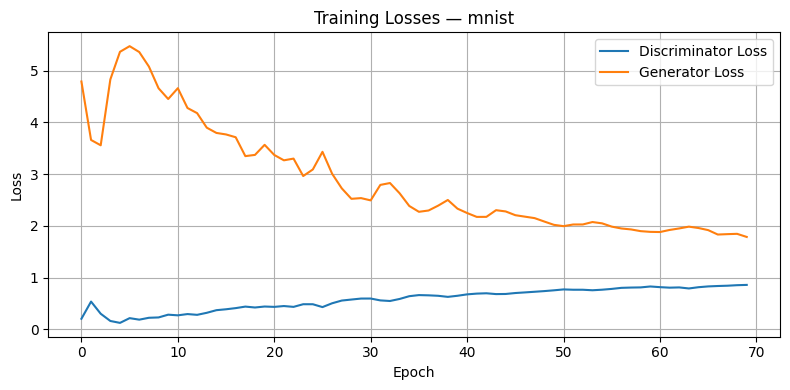

Saved generator     -> /content/drive/MyDrive/saved_models/gan_generator_mnist.pth
Saved discriminator -> /content/drive/MyDrive/saved_models/gan_discriminator_mnist.pth


In [ ]:
gan_mnist = GAN(dataset='mnist')
gan_mnist.train(num_epochs=70)
gan_mnist.show_generated_images()
gan_mnist.plot_losses()
gan_mnist.save_models()

Using device: cuda
Loaded: fashion | 60,000 samples

Training on fashion for 70 epochs...

Epoch [  1/70] | Loss D: 0.1914 | Loss G: 4.3130
Epoch [  2/70] | Loss D: 0.0604 | Loss G: 5.9989
Epoch [  3/70] | Loss D: 0.1063 | Loss G: 6.2208
Epoch [  4/70] | Loss D: 0.1447 | Loss G: 5.8382
Epoch [  5/70] | Loss D: 0.2123 | Loss G: 4.9499
Epoch [  6/70] | Loss D: 0.2574 | Loss G: 4.2300
Epoch [  7/70] | Loss D: 0.2967 | Loss G: 4.1353
Epoch [  8/70] | Loss D: 0.3011 | Loss G: 4.2133
Epoch [  9/70] | Loss D: 0.3676 | Loss G: 3.6878
Epoch [ 10/70] | Loss D: 0.3933 | Loss G: 3.6775
Epoch [ 11/70] | Loss D: 0.4337 | Loss G: 3.3946
Epoch [ 12/70] | Loss D: 0.4635 | Loss G: 3.2963
Epoch [ 13/70] | Loss D: 0.4680 | Loss G: 3.3325
Epoch [ 14/70] | Loss D: 0.4834 | Loss G: 3.2820
Epoch [ 15/70] | Loss D: 0.5059 | Loss G: 3.0768
Epoch [ 16/70] | Loss D: 0.5185 | Loss G: 3.1485
Epoch [ 17/70] | Loss D: 0.5446 | Loss G: 3.2206
Epoch [ 18/70] | Loss D: 0.5926 | Loss G: 2.9834
Epoch [ 19/70] | Loss D: 0.

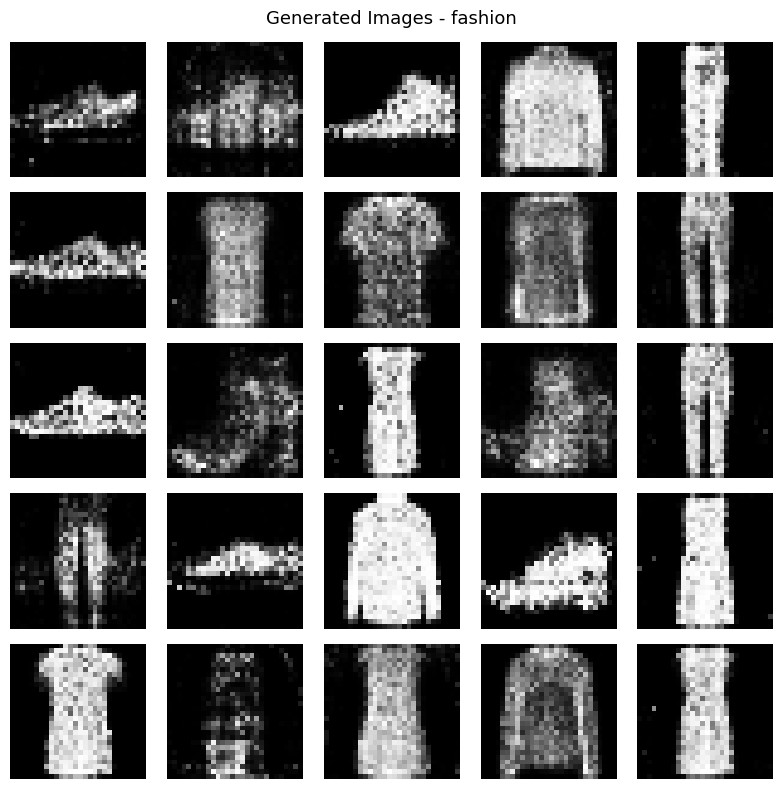

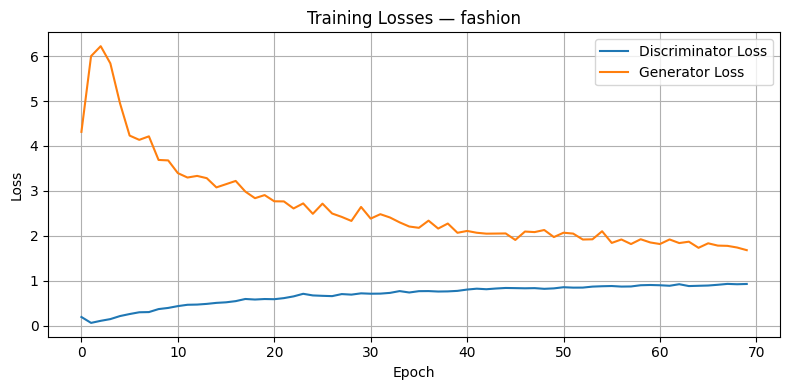

Saved generator     -> /content/drive/MyDrive/saved_models/gan_generator_fashion.pth
Saved discriminator -> /content/drive/MyDrive/saved_models/gan_discriminator_fashion.pth


In [ ]:
gan_fashion = GAN(dataset='fashion')
gan_fashion.train(num_epochs=70)
gan_fashion.show_generated_images()
gan_fashion.plot_losses()
gan_fashion.save_models()

Using device: cuda
Loaded: combined | 120,000 samples

Training on combined for 70 epochs...

Epoch [  1/70] | Loss D: 0.2607 | Loss G: 4.5184
Epoch [  2/70] | Loss D: 0.1395 | Loss G: 5.2567
Epoch [  3/70] | Loss D: 0.1600 | Loss G: 5.9787
Epoch [  4/70] | Loss D: 0.2081 | Loss G: 5.3785
Epoch [  5/70] | Loss D: 0.2486 | Loss G: 5.0410
Epoch [  6/70] | Loss D: 0.3149 | Loss G: 4.4640
Epoch [  7/70] | Loss D: 0.3492 | Loss G: 4.0130
Epoch [  8/70] | Loss D: 0.3854 | Loss G: 3.7422
Epoch [  9/70] | Loss D: 0.4019 | Loss G: 3.5907
Epoch [ 10/70] | Loss D: 0.4811 | Loss G: 3.3592
Epoch [ 11/70] | Loss D: 0.4964 | Loss G: 3.0580
Epoch [ 12/70] | Loss D: 0.5438 | Loss G: 2.9612
Epoch [ 13/70] | Loss D: 0.5204 | Loss G: 2.9419
Epoch [ 14/70] | Loss D: 0.5320 | Loss G: 2.8393
Epoch [ 15/70] | Loss D: 0.5606 | Loss G: 2.8002
Epoch [ 16/70] | Loss D: 0.5527 | Loss G: 2.7270
Epoch [ 17/70] | Loss D: 0.5640 | Loss G: 2.7071
Epoch [ 18/70] | Loss D: 0.6007 | Loss G: 2.5403
Epoch [ 19/70] | Loss D:

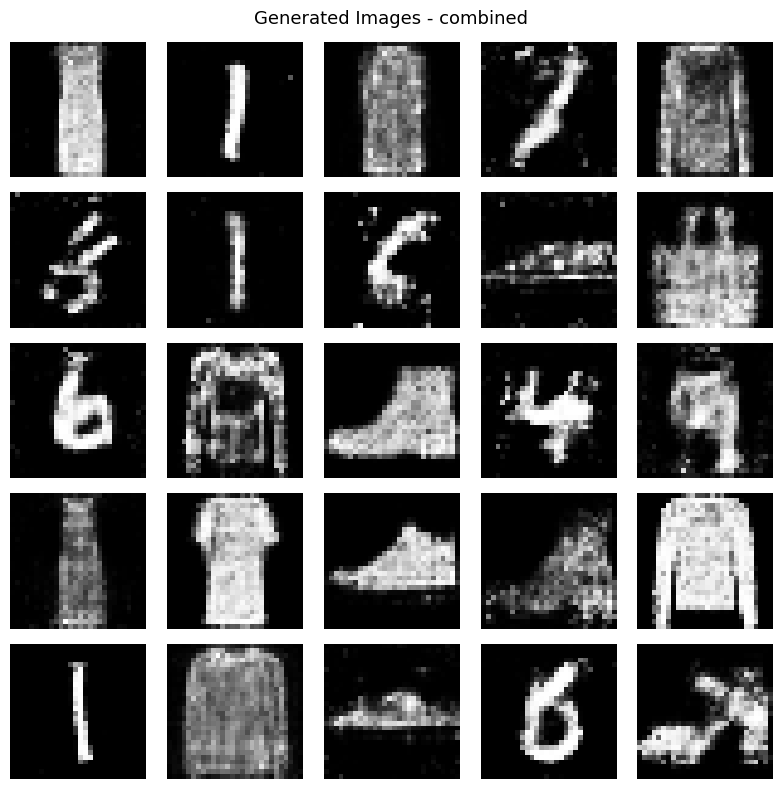

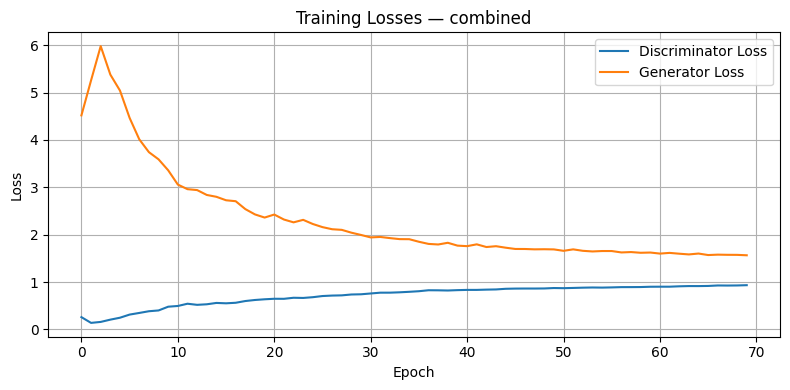

Saved generator     -> /content/drive/MyDrive/saved_models/gan_generator_combined.pth
Saved discriminator -> /content/drive/MyDrive/saved_models/gan_discriminator_combined.pth


In [10]:
gan_combined = GAN(dataset='combined')
gan_combined.train(num_epochs=70)
gan_combined.show_generated_images()
gan_combined.plot_losses()
gan_combined.save_models()

In [17]:
def load_and_generate(dataset_name, n=25, latent_dim=100):
    g_path = os.path.join(SAVE_DIR, f'gan_generator_{dataset_name}.pth')
    G = Generator(latent_dim).to(device)
    G.load_state_dict(torch.load(g_path, map_location=device))
    G.eval()

    print(f'Loaded generator from -> {g_path}')

    # generate images
    z = torch.randn(n, latent_dim).to(device)
    with torch.no_grad():
        fake_imgs = G(z)

    # display
    cols = int(n ** 0.5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
    axes = axes.flatten()
    for i in range(n):
        img = fake_imgs[i].squeeze().cpu().numpy()
        img = (img + 1) / 2          # rescale [-1,1] → [0,1] for display
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
    for i in range(n, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f'Loaded Generator — {dataset_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

Loaded generator from -> /content/drive/MyDrive/saved_models/gan_generator_mnist.pth


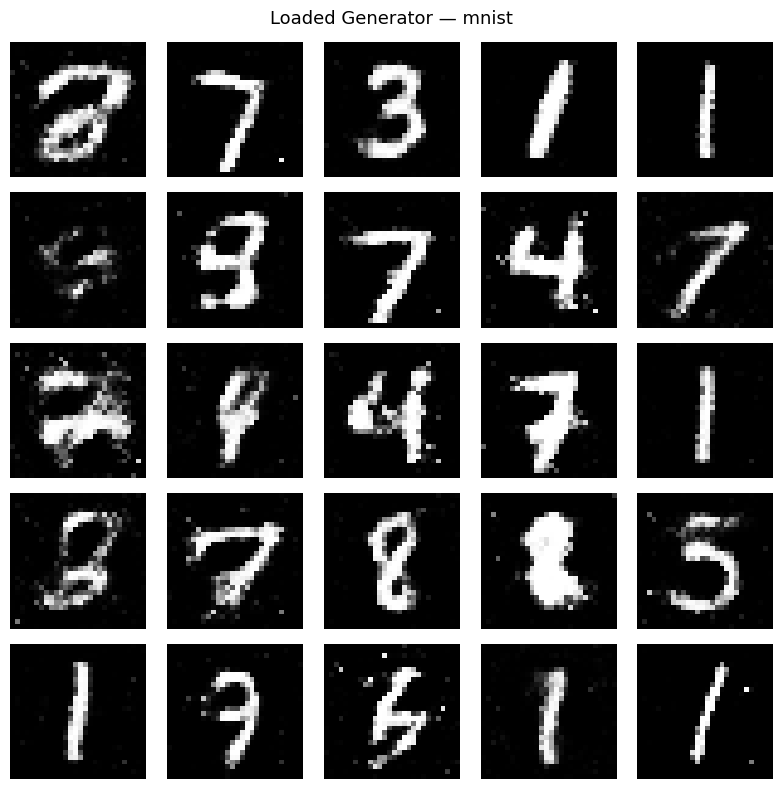

Loaded generator from -> /content/drive/MyDrive/saved_models/gan_generator_fashion.pth


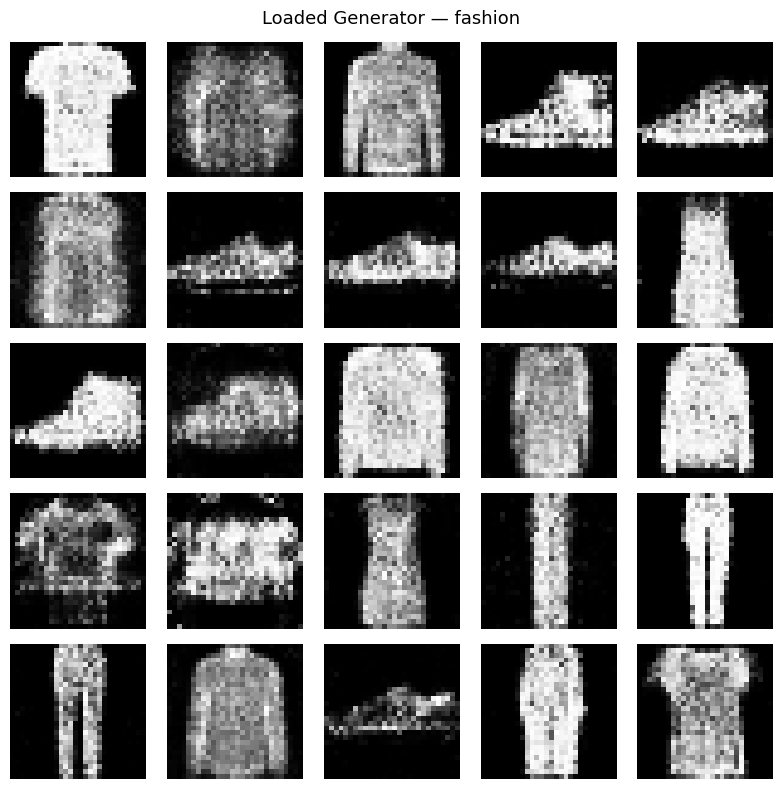

Loaded generator from -> /content/drive/MyDrive/saved_models/gan_generator_combined.pth


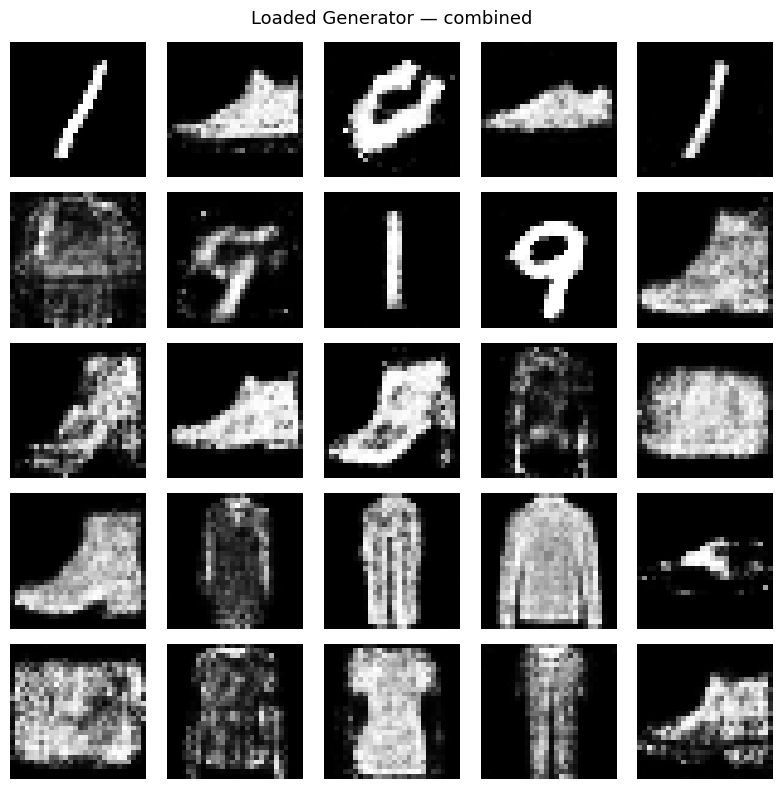

In [20]:
load_and_generate('mnist')
load_and_generate('fashion')
load_and_generate('combined')